# Image Processing — Performance Analysis
**High Performance Computing · 7th Quarter · UPY**

This notebook benchmarks three image filters — **Gaussian**, **Sobel**, and **Median** — implemented in three different ways: Pure Python, NumPy, and NumPy + Cython. The goal is to measure and compare execution times across approaches.

> **Requirement:** compile the Cython extension before running.
> ```bash
> python setup.py build_ext --inplace
> ```

In [12]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cv2

from filters_python import gaussian_python, sobel_python, median_python
from filters_numpy  import gaussian_numpy,  sobel_numpy,  median_numpy
from filters_cython import gaussian_cython, sobel_cython, median_cython

print('All modules loaded successfully.')

All modules loaded successfully.


## 1 · Load Image
Load `test_image.jpg`, convert it to grayscale, and prepare the three input formats required by each implementation.

Image loaded — shape: (1024, 768), dtype: uint8


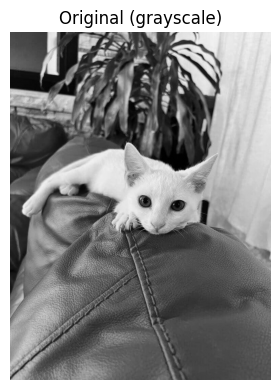

In [13]:
img = cv2.imread('test_image.jpg', cv2.IMREAD_GRAYSCALE)
assert img is not None, "Could not load 'test_image.jpg'. Place it in the repo root."

img_list  = img.tolist()            # Pure Python works with nested lists
img_float = img.astype(np.float64)  # Cython requires a float64 memoryview

print(f'Image loaded — shape: {img.shape}, dtype: {img.dtype}')

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap='gray')
plt.title('Original (grayscale)')
plt.axis('off')
plt.tight_layout()
plt.show()

## 2 · Benchmark
Each filter runs **5 times** per implementation. We record the **median** time to avoid spikes caused by background OS processes.

In [14]:
N_RUNS = 5

def bench(func, arg, n=N_RUNS):
    """Run func(arg) n times and return (result, median_time)."""
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        result = func(arg)
        times.append(time.perf_counter() - t0)
    return result, float(np.median(times))

print(f'Running each filter {N_RUNS} times — recording median time...\n')

results = {}   # filtered images
timings = {}   # timings[(filter_name, approach)] = seconds

schedule = [
    ('Gaussian', gaussian_python, img_list,  gaussian_numpy, img, gaussian_cython, img_float),
    ('Sobel',    sobel_python,    img_list,  sobel_numpy,    img, sobel_cython,    img_float),
    ('Median',   median_python,   img_list,  median_numpy,   img, median_cython,   img_float),
]

for filter_name, fn_py, arg_py, fn_np, arg_np, fn_cy, arg_cy in schedule:
    results[filter_name] = {}

    res, t = bench(fn_py, arg_py)
    results[filter_name]['Python'] = res
    timings[(filter_name, 'Pure Python')] = t
    print(f'{filter_name:<10} Pure Python   : {t:.4f} s')

    res, t = bench(fn_np, arg_np)
    results[filter_name]['NumPy'] = res
    timings[(filter_name, 'NumPy')] = t
    print(f'{filter_name:<10} NumPy         : {t:.4f} s')

    res, t = bench(fn_cy, arg_cy)
    results[filter_name]['Cython'] = res
    timings[(filter_name, 'NumPy + Cython')] = t
    print(f'{filter_name:<10} NumPy + Cython: {t:.4f} s')
    print()

Running each filter 5 times — recording median time...

Gaussian   Pure Python   : 0.7516 s
Gaussian   NumPy         : 0.0050 s
Gaussian   NumPy + Cython: 0.0009 s

Sobel      Pure Python   : 1.7407 s
Sobel      NumPy         : 0.0143 s
Sobel      NumPy + Cython: 0.0015 s

Median     Pure Python   : 0.2205 s
Median     NumPy         : 0.0269 s
Median     NumPy + Cython: 0.0058 s



## 3 · Results Table
Execution times with **speedup factors** — how many times faster each approach is compared to Pure Python (and Cython vs NumPy).

In [15]:
filters     = ['Gaussian', 'Sobel', 'Median']
approaches  = ['Pure Python', 'NumPy', 'NumPy + Cython']

data = {app: [timings[(f, app)] for f in filters] for app in approaches}
df = pd.DataFrame(data, index=filters)
df.index.name = 'Filter'

# Speedup = how many times faster vs the reference
df['Speedup NumPy / Python']   = df['Pure Python'] / df['NumPy']
df['Speedup Cython / Python']  = df['Pure Python'] / df['NumPy + Cython']
df['Speedup Cython / NumPy']   = df['NumPy']        / df['NumPy + Cython']

time_cols   = approaches
speed_cols  = [c for c in df.columns if 'Speedup' in c]

styled = (df.style
    .format({c: '{:.4f} s' for c in time_cols})
    .format({c: '{:.1f}x'  for c in speed_cols})
    .background_gradient(subset=time_cols,  cmap='RdYlGn_r')
    .background_gradient(subset=speed_cols, cmap='YlGn')
    .set_caption('Table 1 — Median execution time over 5 runs + speedup factors')
)
styled

,Pure Python,NumPy,NumPy + Cython,Speedup NumPy / Python,Speedup Cython / Python,Speedup Cython / NumPy
Filter,,,,,,
Gaussian,0.751641,0.004984,0.000902,150.8x,833.0x,5.5x
Sobel,1.740659,0.014302,0.001533,121.7x,1135.2x,9.3x
Median,0.220520,0.026868,0.005811,8.2x,37.9x,4.6x


## 4 · Bar Charts
Two views of the same data: **linear scale** (left) shows the overall gap between approaches; **log scale** (right) makes the NumPy vs Cython difference visible.

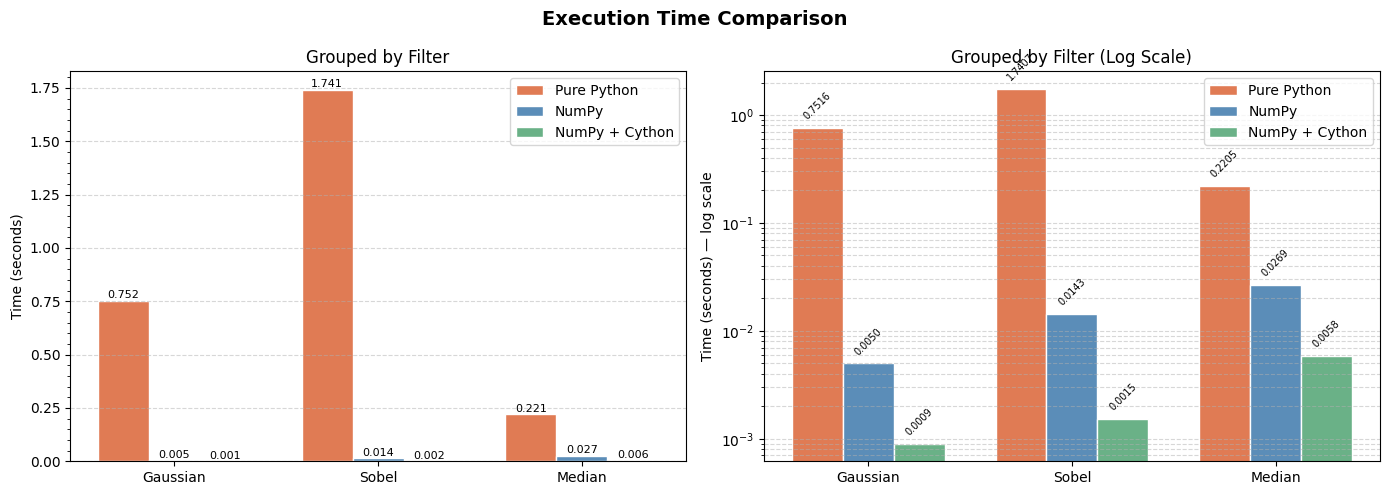

In [16]:
colors = {'Pure Python': '#e07b54', 'NumPy': '#5b8db8', 'NumPy + Cython': '#6ab187'}
x      = np.arange(len(filters))
width  = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Execution Time Comparison', fontsize=14, fontweight='bold')

# --- Left: linear scale ---
ax = axes[0]
for i, approach in enumerate(approaches):
    vals = [timings[(f, approach)] for f in filters]
    bars = ax.bar(x + i * width, vals, width, label=approach, color=colors[approach], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(filters)
ax.set_ylabel('Time (seconds)')
ax.set_title('Grouped by Filter')
ax.legend()
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis='y', linestyle='--', alpha=0.5)

# --- Right: log scale (NumPy vs Cython gap becomes visible) ---
ax2 = axes[1]
for i, approach in enumerate(approaches):
    vals = [timings[(f, approach)] for f in filters]
    bars = ax2.bar(x + i * width, vals, width, label=approach, color=colors[approach], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.15,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax2.set_xticks(x + width)
ax2.set_xticklabels(filters)
ax2.set_ylabel('Time (seconds) — log scale')
ax2.set_title('Grouped by Filter (Log Scale)')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.5, which='both')

plt.tight_layout()
plt.savefig('benchmark_bar_chart.png', dpi=150)
plt.show()

## 5 · Speedup Heatmap
Each cell shows how many times faster one approach is over another. Darker green = bigger gain.

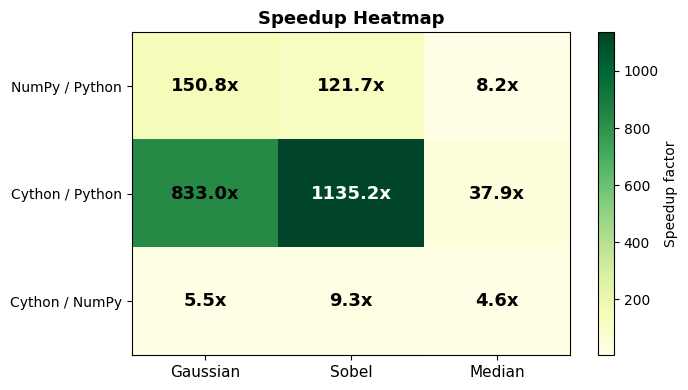

In [17]:
speedup_labels = ['NumPy / Python', 'Cython / Python', 'Cython / NumPy']
speedup_data   = np.array([
    [timings[(f, 'Pure Python')] / timings[(f, 'NumPy')]          for f in filters],
    [timings[(f, 'Pure Python')] / timings[(f, 'NumPy + Cython')] for f in filters],
    [timings[(f, 'NumPy')]       / timings[(f, 'NumPy + Cython')] for f in filters],
])

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(speedup_data, cmap='YlGn', aspect='auto')

ax.set_xticks(range(len(filters)))
ax.set_xticklabels(filters, fontsize=11)
ax.set_yticks(range(len(speedup_labels)))
ax.set_yticklabels(speedup_labels, fontsize=10)

for i in range(len(speedup_labels)):
    for j in range(len(filters)):
        val = speedup_data[i, j]
        color = 'black' if val < speedup_data.max() * 0.75 else 'white'
        ax.text(j, i, f'{val:.1f}x', ha='center', va='center',
                fontsize=13, fontweight='bold', color=color)

plt.colorbar(im, ax=ax, label='Speedup factor')
ax.set_title('Speedup Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('benchmark_heatmap.png', dpi=150)
plt.show()

## 6 · Visual Results
Side-by-side comparison of the original image and each filtered output. Titles include the measured execution time.

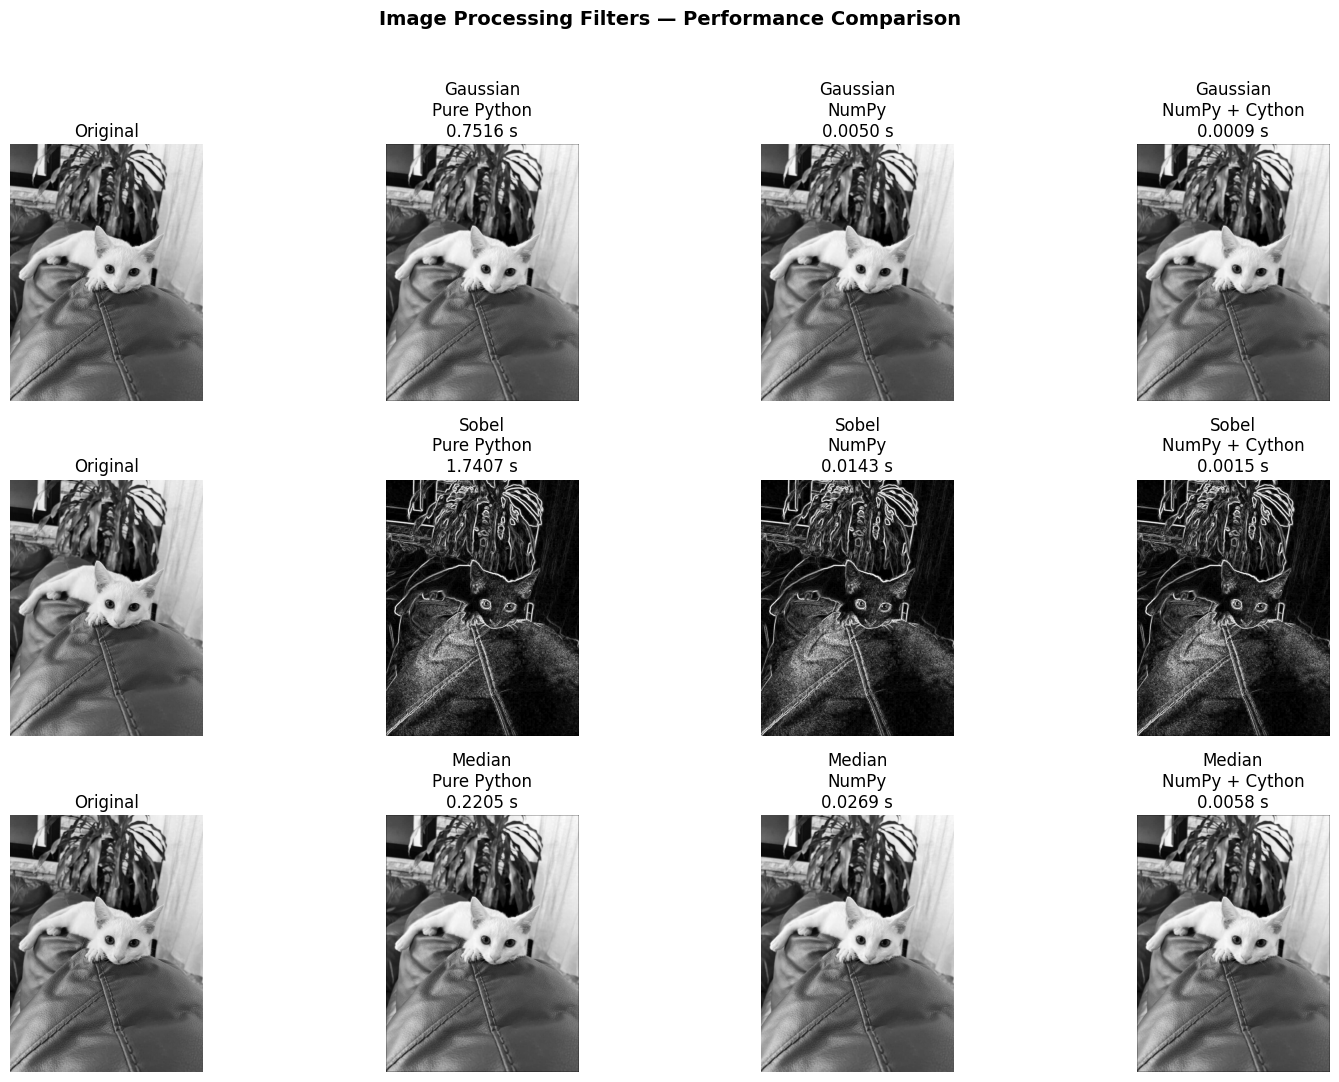

In [18]:
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle('Image Processing Filters — Performance Comparison', fontsize=14, fontweight='bold')

plot_layout = [
    ('Gaussian', results['Gaussian']['Python'], results['Gaussian']['NumPy'], results['Gaussian']['Cython']),
    ('Sobel',    results['Sobel']['Python'],    results['Sobel']['NumPy'],    results['Sobel']['Cython']),
    ('Median',   results['Median']['Python'],   results['Median']['NumPy'],   results['Median']['Cython']),
]

for row, (fname, res_py, res_np, res_cy) in enumerate(plot_layout):
    t_py = timings[(fname, 'Pure Python')]
    t_np = timings[(fname, 'NumPy')]
    t_cy = timings[(fname, 'NumPy + Cython')]

    axes[row, 0].imshow(img, cmap='gray');       axes[row, 0].set_title('Original');                                 axes[row, 0].axis('off')
    axes[row, 1].imshow(res_py, cmap='gray');    axes[row, 1].set_title(f'{fname}\nPure Python\n{t_py:.4f} s');     axes[row, 1].axis('off')
    axes[row, 2].imshow(res_np, cmap='gray');    axes[row, 2].set_title(f'{fname}\nNumPy\n{t_np:.4f} s');           axes[row, 2].axis('off')
    axes[row, 3].imshow(res_cy, cmap='gray');    axes[row, 3].set_title(f'{fname}\nNumPy + Cython\n{t_cy:.4f} s'); axes[row, 3].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('comparative_visualization.png', dpi=150)
plt.show()

## 7 · Pixel Intensity Histograms
Shows how each filter changes the pixel intensity distribution. The **gray overlay** is the original image — use it as a reference to see what the filter shifts.

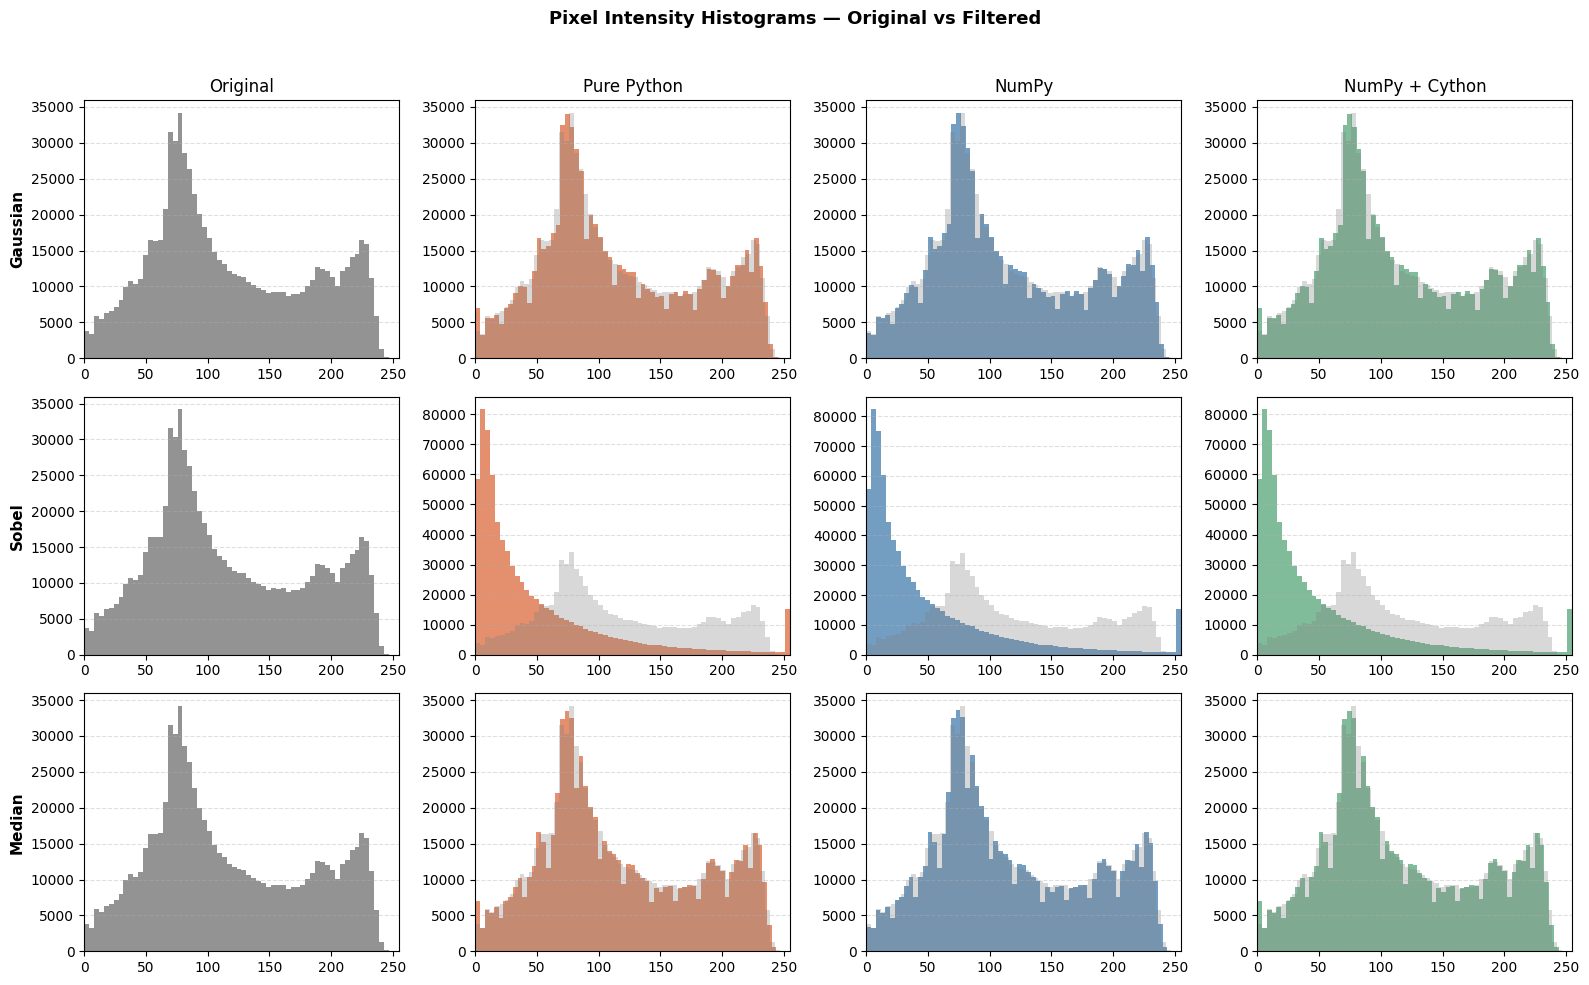

In [19]:
def to_array(data):
    """Convert a nested list or ndarray to a flat uint8 numpy array."""
    arr = np.array(data, dtype=np.float32)
    arr = np.clip(arr, 0, 255).astype(np.uint8)
    return arr.ravel()

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Pixel Intensity Histograms — Original vs Filtered', fontsize=13, fontweight='bold')

bins = 64
original_flat = img.ravel()

for row, fname in enumerate(['Gaussian', 'Sobel', 'Median']):
    ax_orig = axes[row, 0]
    ax_orig.hist(original_flat, bins=bins, color='gray', edgecolor='none', alpha=0.85)
    ax_orig.set_title(f'Original' if row == 0 else '')
    ax_orig.set_ylabel(fname, fontsize=11, fontweight='bold')
    ax_orig.set_xlim(0, 255)
    ax_orig.grid(axis='y', linestyle='--', alpha=0.4)

    for col, (approach_key, color, label) in enumerate([
        ('Python', colors['Pure Python'],   'Pure Python'),
        ('NumPy',  colors['NumPy'],         'NumPy'),
        ('Cython', colors['NumPy + Cython'],'NumPy + Cython'),
    ]):
        ax = axes[row, col + 1]
        flat = to_array(results[fname][approach_key])
        ax.hist(flat, bins=bins, color=color, edgecolor='none', alpha=0.85)
        ax.hist(original_flat, bins=bins, color='gray', edgecolor='none', alpha=0.3)  # reference overlay
        if row == 0:
            ax.set_title(label)
        ax.set_xlim(0, 255)
        ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('benchmark_histograms.png', dpi=150)
plt.show()

## 8 · Key Observations

### Performance trend
- **Pure Python** is the slowest — every pixel is processed one by one through the Python interpreter.
- **NumPy** is significantly faster because array operations are executed by optimized C libraries under the hood.
- **NumPy + Cython** is the fastest for Gaussian and Sobel — the loops are compiled directly to C, eliminating Python interpreter overhead entirely.

### Why Cython doesn't always win on Median
The Median filter is a special case. `np.median` uses an **introselect algorithm** (a highly optimized partial sort in C). The Cython version uses a **bubble sort** on 9 elements per pixel, which can't match that. Cython helps the most when the bottleneck is Python loop overhead — not when NumPy already has a purpose-built C routine for the operation.

### Trade-off summary

| Approach | Ease of implementation | Speed |
|---|---|---|
| Pure Python | Easy — plain loops, no dependencies | Slowest (baseline) |
| NumPy | Easy — concise, readable array ops | ~10–170× faster |
| NumPy + Cython | Hard — static types, compilation step | ~38–1000× faster |